# 📊 Exploratory Data Analysis (EDA) – Sales Dataset

## Import Required Libraries

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Show all columns properly
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

print("Libraries imported successfully")

Libraries imported successfully


## Load Dataset

In [14]:
df = pd.read_csv('../desktop/Sales Dataset.csv')

#from IPython.display import display

## Data Overview

In [5]:
# Show dataset shape

rows, cols = df.shape

overview = pd.DataFrame({
    "Metric": ["Number of Rows", "Number of Columns"],
    "Value": [rows, cols]
})

overview

,Metric,Value
0,Number of Rows,1194
1,Number of Columns,12


##  Missing Value Analysis

In [15]:
missing = df.isnull().sum()

missing_table = pd.DataFrame({
    "Column Name": missing.index,
    "Missing Values": missing.values
})

# Display clean table
display(missing_table.style.hide(axis="index"))

# Check total missing values
total_missing = missing.sum()

print("\nTotal Missing Values in Dataset:", total_missing)

Column Name,Missing Values
Order ID,0
Amount,0
Profit,0
Quantity,0
Category,0
Sub-Category,0
PaymentMode,0
Order Date,0
CustomerName,0
State,0



Total Missing Values in Dataset: 0


## Date Conversion

In [7]:
# Convert date column properly
df['Order Date'] = pd.to_datetime(df['Order Date'], errors='coerce')

# Remove time portion (keep only date)
df['Order Date'] = df['Order Date'].dt.date

# Create clean display table with SR number
date_table = pd.DataFrame({
    "SR No": range(1, len(df['Order Date'].head()) + 1),
    "Order Date": df['Order Date'].head().values
})

# Display without default index
date_table.style.hide(axis="index")

SR No,Order Date
1,2023-06-27
2,2024-12-27
3,2021-07-25
4,2023-06-27
5,2024-12-27


## Descriptive Statistics

In [8]:
# Statistics table

df[['Amount','Profit','Quantity']].describe().round(2)

,Amount,Profit,Quantity
count,1194.00,1194.00,1194.00
mean,5178.09,1348.99,10.67
std,2804.92,1117.99,5.78
min,508.00,50.00,1.00
25%,2799.00,410.00,6.00
50%,5152.00,1014.00,11.00
75%,7626.00,2035.00,16.00
max,9992.00,4930.00,20.00


## Sales Trend Analysis

In [9]:
# Create Year-Month column
df['YearMonth'] = pd.to_datetime(df['Order Date'])
df['YearMonth'] = df['YearMonth'].dt.to_period('M')

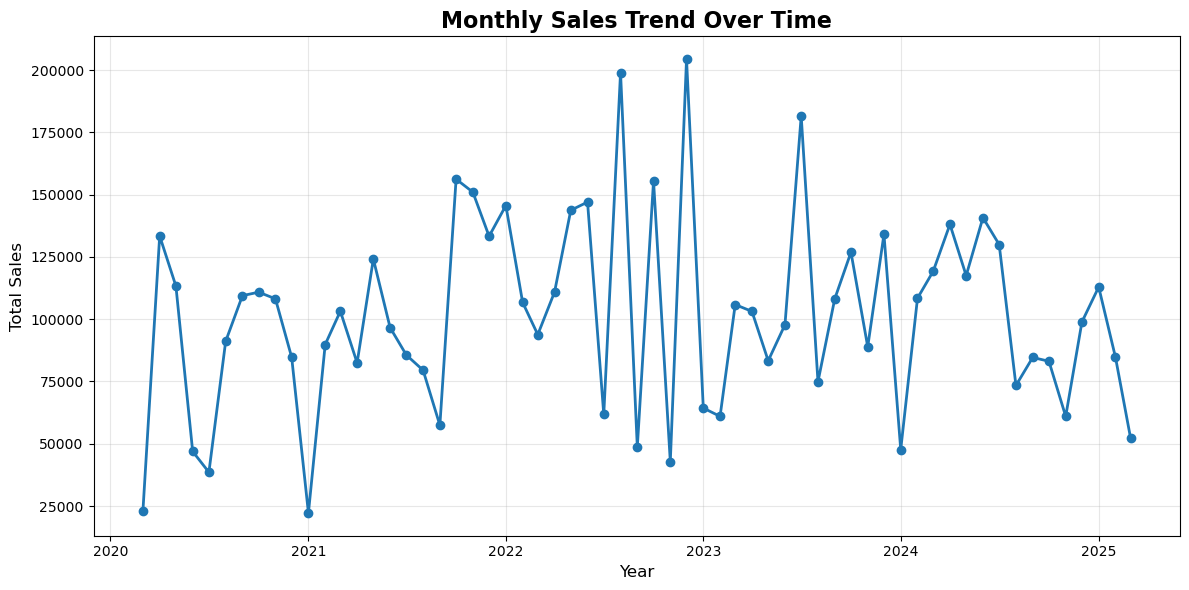

In [10]:
import matplotlib.pyplot as plt

# Group monthly sales
monthly_sales = df.groupby('YearMonth')['Amount'].sum()

# Convert Period to Timestamp for better plotting
monthly_sales.index = monthly_sales.index.to_timestamp()

plt.figure(figsize=(12,6))

plt.plot(
    monthly_sales.index,
    monthly_sales.values,
    marker='o',
    linewidth=2
)

plt.title("Monthly Sales Trend Over Time", fontsize=16, fontweight='bold')
plt.xlabel("Year", fontsize=12)
plt.ylabel("Total Sales", fontsize=12)

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

Sales fluctuate over time, indicating seasonality and demand variation. This insight supports forecasting and inventory planning.

##  Correlation Analysis

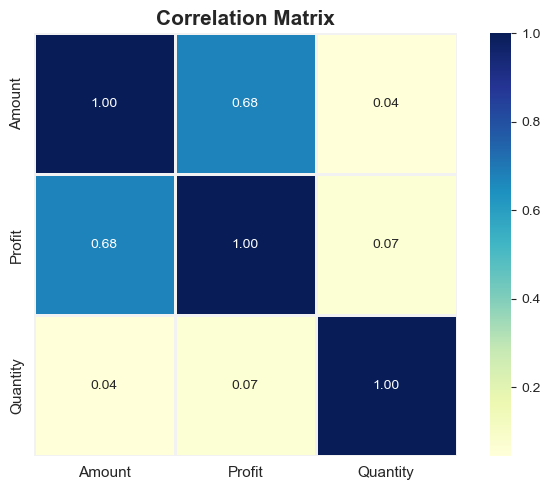

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select numeric columns
numeric_data = df[['Amount', 'Profit', 'Quantity']]
corr = numeric_data.corr()

# Set clean background style
sns.set_style("white")

plt.figure(figsize=(7,5))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="YlGnBu",        # soft sky blue professional palette
    square=True,
    linewidths=1,
    linecolor="#F2F2F2",
    cbar=True
)

plt.title("Correlation Matrix", fontsize=15, fontweight='bold')
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)

plt.tight_layout()
plt.show()

Sales and Profit show moderate positive correlation, suggesting revenue growth supports profitability. Quantity has limited impact on profit.

## Outlier Detection

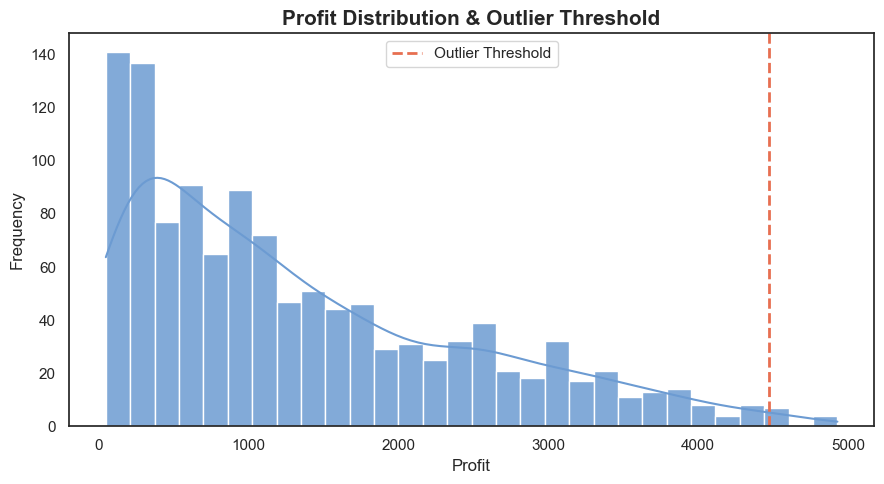

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

sns.set_theme(style="white")

plt.figure(figsize=(9,5))

# Histogram + KDE
sns.histplot(
    df['Profit'],
    bins=30,
    kde=True,
    color="#6C9BD2",      # soft professional blue
    edgecolor="white",
    alpha=0.85
)

# Highlight extreme outliers using IQR
Q1 = df['Profit'].quantile(0.25)
Q3 = df['Profit'].quantile(0.75)
IQR = Q3 - Q1

upper_bound = Q3 + 1.5 * IQR

plt.axvline(upper_bound, color="#E76F51", linestyle="--", linewidth=2, label="Outlier Threshold")

plt.title("Profit Distribution & Outlier Threshold", fontsize=15, fontweight="bold")
plt.xlabel("Profit")
plt.ylabel("Frequency")

plt.legend()
plt.tight_layout()
plt.show()

Most profit values fall within a normal range, while a few extreme transactions exceed the statistical threshold. These may represent premium opportunities or pricing anomalies.

## Key Business Insights

1. Revenue growth contributes to profitability, but sustainable margin management is essential.

2. Increasing sales volume alone does not significantly improve profit, emphasizing the need for pricing optimization.

3. High-profit outliers indicate potential premium strategies that can be analyzed and replicated.

# 📄 Executive Summary

This analysis examined sales trends, profitability relationships, and extreme transaction behavior. Revenue growth contributes to profitability; however, increasing sales volume alone does not guarantee improved margins. Outlier analysis identified high-profit transactions that may indicate strategic opportunities. The findings support data-driven pricing, forecasting, and margin optimization decisions.

---
**End of Analysis**